In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np
import locale

import matplotlib.dates as mdates

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df = pd.read_csv("C:/Users/s22v_/Documents/data_analyst_job_market/data/processed/month_dataset_20260312_190938.csv")



FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/s22v_/Documents/data_analyst_job_market/data/processed/month_dataset_20260312_190938.csv'

In [ ]:
df['published_at'] = pd.to_datetime(df['published_at'])
df['date'] = df['published_at'].dt.date
df['weekday'] = df['published_at'].dt.day_name()
df['weekday_num'] = df['published_at'].dt.weekday
df['hour'] = df['published_at'].dt.hour

df['date_dt'] = pd.to_datetime(df['date'])

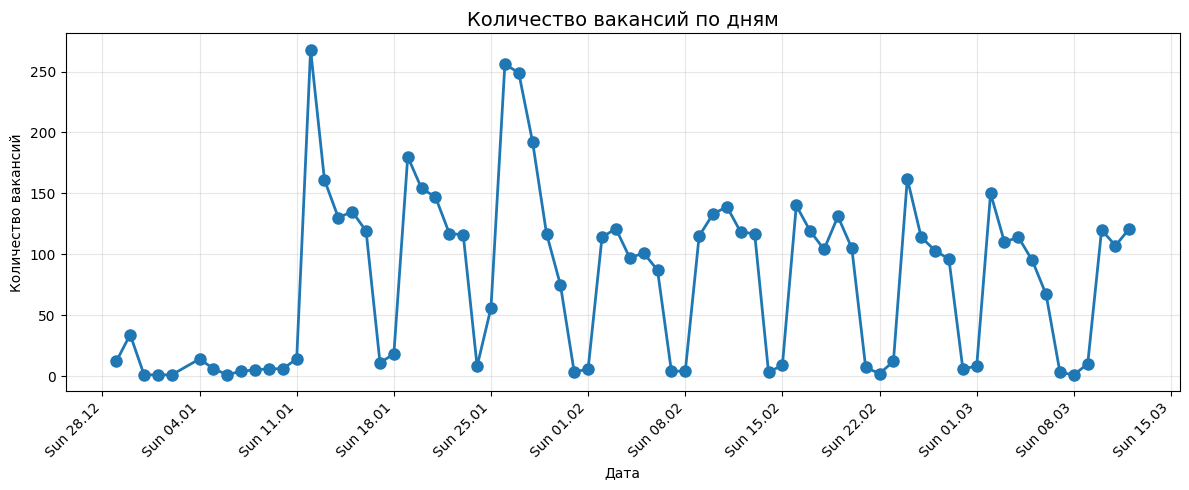

In [ ]:

plt.figure(figsize=(12, 5))
daily = df.groupby('date_dt').size()
daily.plot(kind='line', marker='o', linewidth=2, markersize=8)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=6))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%a %d.%m'))  
plt.title('Количество вакансий по дням', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество вакансий')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

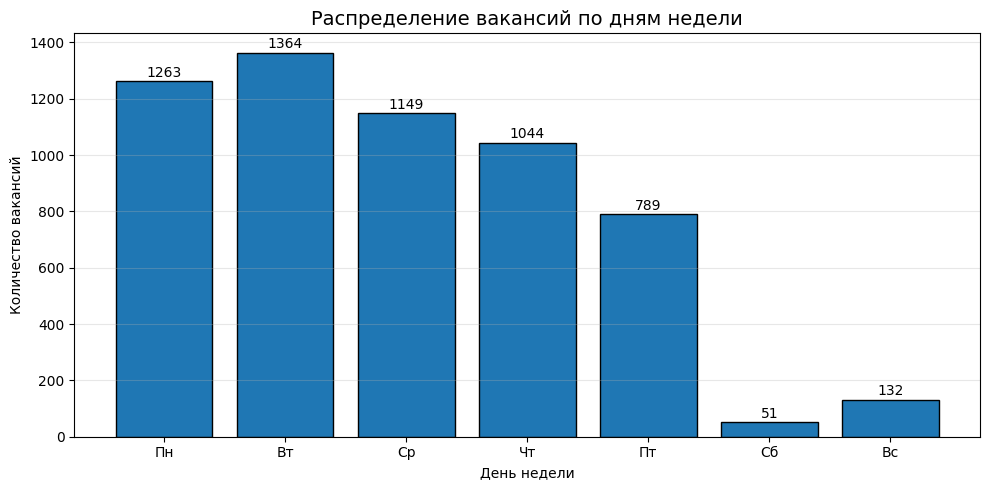

In [ ]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_names_ru = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

weekday_counts = df['weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10, 5))
bars = plt.bar(weekday_names_ru, weekday_counts.values, edgecolor='black')
plt.title('Распределение вакансий по дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Количество вакансий')
plt.grid(True, alpha=0.3, axis='y')


for bar, val in zip(bars, weekday_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [4]:
a = pd.read_csv('../finaldata/month_dataset_20260420_205719.csv')

a

,id,premium,name,department,has_test,response_letter_required,published_at,accept_labor_contract,salary_from,salary_to,...,working_hours_name,work_schedule_name,employment_form_id,employment_form_name,department_id,department_name,min_experience_years,avg_experience_years,skills_list,skills_count
0,129951975,False,Аналитик данных (операционная аналитика),NaN,True,False,2026-01-28 11:17:36+03:00,True,NaN,NaN,...,8 часов,5/2,FULL,Полная,NaN,NaN,NaN,NaN,NaN,NaN
1,129872910,False,Начинающий аналитик данных,NaN,False,False,2026-01-26 13:19:34+03:00,True,115000.0,NaN,...,8 часов,5/2,FULL,Полная,NaN,NaN,NaN,NaN,NaN,NaN
2,129807946,False,Младший аналитик данных (стажер),NaN,True,False,2026-01-23 15:50:49+03:00,False,NaN,NaN,...,8 часов,5/2,FULL,Полная,NaN,NaN,NaN,NaN,NaN,NaN
3,129602300,False,Младший аналитик данных,NaN,False,False,2026-01-19 14:47:59+03:00,False,80000.0,NaN,...,8 часов,5/2,FULL,Полная,NaN,NaN,NaN,NaN,NaN,NaN
4,129963521,False,Аналитик данных,NaN,False,False,2026-01-28 14:18:35+03:00,True,NaN,NaN,...,8 часов,5/2,FULL,Полная,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7798,131917087,False,Системный аналитик ИТ (главный специалист),NaN,False,False,2026-04-07 14:00:45+03:00,False,60000.0,80000.0,...,8 часов,5/2,FULL,Полная,NaN,NaN,1.0,2.0,[],0.0
7799,131231109,False,Младший системный аналитик,NaN,False,True,2026-03-16 05:29:35+03:00,False,NaN,10000.0,...,2 часа,6/1,FLY_IN_FLY_OUT,Вахта,NaN,NaN,1.0,2.0,['Аналитическое мышление'],1.0
7800,131930388,False,Системный аналитик,NaN,False,False,2026-04-07 19:19:06+03:00,True,NaN,NaN,...,8 часов,5/2,FULL,Полная,NaN,NaN,3.0,4.0,[],0.0
7801,131907647,False,Системный аналитик,NaN,False,False,2026-04-07 11:50:37+03:00,True,NaN,NaN,...,8 часов,5/2,FULL,Полная,3529-3529-it,Сбер. IT,3.0,4.0,"['Продуктовая аналитика', 'Машинное обучение',...",3.0
